# Задача №2: Сравнение методов прогнозирования временного ряда ежемесячных запусков

**Содержание:**
1. Подготовка данных и импорт библиотек
2. Разделение на тренировочный и тестовый периоды
3. Бейзлайн: наивные модели (Naive, SeasonalNaive)
4. Ручная модель ARIMA (подбор параметров по ACF/PACF)
5. Автоматические модели (AutoARIMA, AutoETS, Theta)
6. Prophet
7. Кросс-валидация (бектестинг) и сравнение метрик
8. Анализ остатков лучшей модели
9. Вероятностные прогнозы
10. Выводы

In [1]:
!pip install statsforecast prophet utilsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


1. Подготовка данных и импорт библиотек

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, SeasonalNaive,
    AutoARIMA, AutoETS, AutoTheta
)
from utilsforecast.losses import mae, rmse, smape
from utilsforecast.evaluation import evaluate

from prophet import Prophet

# Загрузка и агрегация (повтор, для самодостаточности)
url = 'https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/All%20Space%20Missions%20from%201957/Space_Corrected.csv'
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Unnamed: 0': 'id',
    'Company Name': 'company',
    'Status Rocket': 'rocket_status',
    'Rocket': 'cost_millions',
    'Status Mission': 'mission_status'
})

def parse_mixed_date(date_str):
    date_str = str(date_str).strip()
    if ' UTC' in date_str:
        date_str = date_str.replace(' UTC', '')
        return pd.to_datetime(date_str, format='%a %b %d, %Y %H:%M')
    else:
        return pd.to_datetime(date_str, format='%a %b %d, %Y')

df['Datum'] = df['Datum'].apply(parse_mixed_date)
df = df.dropna(subset=['Datum'])
df.set_index('Datum', inplace=True)
df = df.sort_index()

monthly_launches = df.resample('MS').size()
monthly_launches.name = 'launches'
full_range = pd.date_range(start=monthly_launches.index.min(),
                           end=monthly_launches.index.max(), freq='MS')
monthly_launches = monthly_launches.reindex(full_range, fill_value=0)
monthly_launches.index.freq = 'MS'

print("Целевой ряд готов. Форма:", monthly_launches.shape)
monthly_launches.head()

Целевой ряд готов. Форма: (755,)


,launches
1957-10-01,1
1957-11-01,1
1957-12-01,1
1958-01-01,0
1958-02-01,2


подготовленный ВР (как в 1 задаче)

2. Разделение на тренировочный и тестовый периоды

In [3]:
# последние 12 месяцев для финального теста
test_size = 12
train = monthly_launches.iloc[:-test_size]
test = monthly_launches.iloc[-test_size:]

print(f"Тренировочный период: {train.index[0].date()} – {train.index[-1].date()}, длина: {len(train)}")
print(f"Тестовый период: {test.index[0].date()} – {test.index[-1].date()}, длина: {len(test)}")

Тренировочный период: 1957-10-01 – 2019-08-01, длина: 743
Тестовый период: 2019-09-01 – 2020-08-01, длина: 12


3. Бейзлайн: наивные модели

Используем Naive (прогноз равен последнему значению) и SeasonalNaive (прогноз равен значению сезонного лага - 12 месяцев назад).

In [5]:
train_df = train.reset_index()
train_df.columns = ['ds', 'y']
train_df['unique_id'] = 'launches'

sf_train = train_df[['unique_id', 'ds', 'y']]

models_baseline = [Naive(), SeasonalNaive(season_length=12)]

sf = StatsForecast(models=models_baseline, freq='MS', n_jobs=-1)
forecasts_baseline = sf.forecast(h=test_size, df=sf_train)

test_df = pd.DataFrame({
    'ds': test.index,
    'actual': test.values
})

forecasts_baseline = forecasts_baseline.merge(test_df, on='ds', how='left')

In [7]:
# Оценка метрик
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def calculate_metrics(y_true, y_pred):
    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = denominator > 0
    smape_val = 100 * np.mean(numerator[valid] / denominator[valid])
    return {
        'MAE': mae_val,
        'RMSE': rmse_val,
        'sMAPE': smape_val
    }

metrics_baseline = {}
for model_name in ['Naive', 'SeasonalNaive']:
    y_pred = forecasts_baseline[model_name].values
    y_true = forecasts_baseline['actual'].values
    metrics_baseline[model_name] = calculate_metrics(y_true, y_pred)

print("Метрики наивных моделей на тестовом периоде:")
for name, m in metrics_baseline.items():
    print(f"{name}: MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, sMAPE={m['sMAPE']:.2f}%")

Метрики наивных моделей на тестовом периоде:
Naive: MAE=4.33, RMSE=4.88, sMAPE=46.28%
SeasonalNaive: MAE=2.25, RMSE=3.40, sMAPE=27.74%


**Вывод:** SeasonalNaive работает лучше - ряд имеет сильную сезонность. Эти метрики послужат бейзлайном.

4. Ручная модель ARIMA

Проведём анализ ACF/PACF на тренировочном ряду, определим порядок дифференцирования и параметры. Поскольку ряд имеет тренд и сезонность, сначала сделаем сезонное дифференцирование (период 12)



In [8]:
# Анализ стационарности
def adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1]

print("Исходный ряд:")
p_orig = adf_test(train)
print("\nПосле сезонного дифференцирования (12):")
p_sdiff = adf_test(train.diff(12).dropna())
print("\nПосле сезонного и первого разностного (1):")
p_sdiff_diff = adf_test(train.diff(12).diff(1).dropna())

Исходный ряд:
ADF Statistic: -2.2196
p-value: 0.1992

После сезонного дифференцирования (12):
ADF Statistic: -5.1406
p-value: 0.0000

После сезонного и первого разностного (1):
ADF Statistic: -12.1864
p-value: 0.0000


In [10]:
import os
os.makedirs('results', exist_ok=True)

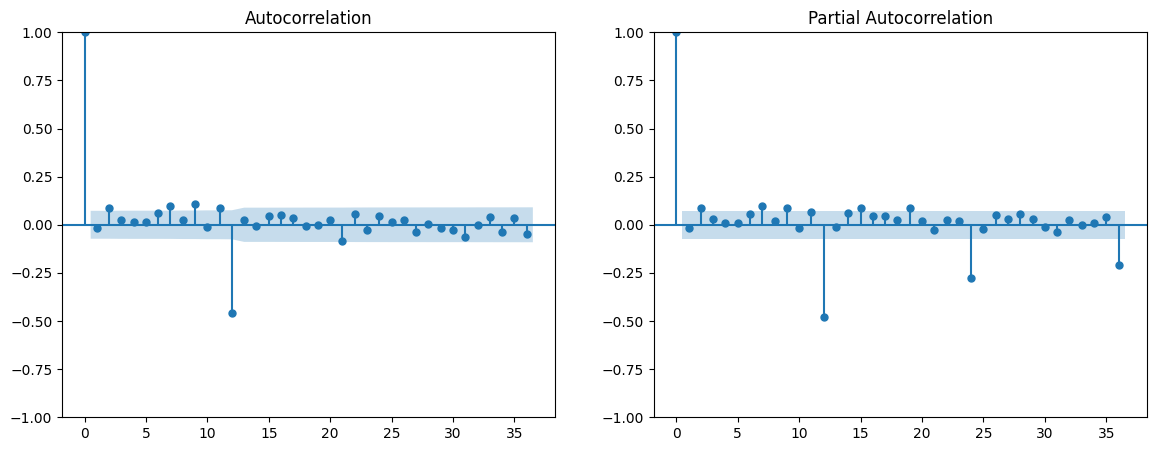

In [12]:
# Графики ACF/PACF для ряда после сезонного дифференцирования
fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_acf(train.diff(12).dropna(), lags=36, ax=axes[0])
plot_pacf(train.diff(12).dropna(), lags=36, ax=axes[1], method='ywm')
plt.savefig('results/1.png', dpi=150, bbox_inches='tight')
plt.show()

На основе графиков предложим модель SARIMA(2,0,0)(0,1,1)[12].

In [13]:
# Ручная SARIMA через statsmodels
manual_arima = SARIMAX(train, order=(2,0,0), seasonal_order=(0,1,1,12),
                      enforce_stationarity=False, enforce_invertibility=False)
manual_arima_fit = manual_arima.fit(disp=False)
print(manual_arima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                             launches   No. Observations:                  743
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood               -1712.746
Date:                              Mon, 08 Jun 2026   AIC                           3433.493
Time:                                      02:10:31   BIC                           3451.799
Sample:                                  10-01-1957   HQIC                          3440.561
                                       - 08-01-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1658      0.032      5.141      0.000       0.103       0.229
ar.L2          0.25

прогноз на тестовый период и сравним

In [14]:
forecast_manual = manual_arima_fit.forecast(steps=test_size)
metrics_manual = calculate_metrics(test.values, forecast_manual)
print(f"Ручная ARIMA(2,0,0)(0,1,1)[12]: MAE={metrics_manual['MAE']:.2f}, RMSE={metrics_manual['RMSE']:.2f}, sMAPE={metrics_manual['sMAPE']:.2f}%")

Ручная ARIMA(2,0,0)(0,1,1)[12]: MAE=2.84, RMSE=3.45, sMAPE=34.61%


5. Автоматические модели (StatsForecast)

AutoARIMA, AutoETS, AutoTheta

In [16]:
models_auto = [AutoARIMA(season_length=12), AutoETS(season_length=12), AutoTheta(season_length=12)]
sf_auto = StatsForecast(models=models_auto, freq='MS', n_jobs=-1)
forecasts_auto = sf_auto.forecast(h=test_size, df=sf_train)

test_df = pd.DataFrame({'ds': test.index, 'actual': test.values})
forecasts_auto = forecasts_auto.merge(test_df, on='ds', how='left')

metrics_auto = {}
for model in ['AutoARIMA', 'AutoETS', 'AutoTheta']:
    y_pred = forecasts_auto[model].values
    y_true = forecasts_auto['actual'].values
    metrics_auto[model] = calculate_metrics(y_true, y_pred)
    print(f"{model}: MAE={metrics_auto[model]['MAE']:.2f}, RMSE={metrics_auto[model]['RMSE']:.2f}, sMAPE={metrics_auto[model]['sMAPE']:.2f}%")

AutoARIMA: MAE=2.91, RMSE=3.47, sMAPE=34.02%
AutoETS: MAE=2.95, RMSE=3.60, sMAPE=34.38%
AutoTheta: MAE=2.97, RMSE=3.61, sMAPE=34.69%


6. Prophet

In [18]:
prophet_train = pd.DataFrame({'ds': train.index, 'y': train.values})

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=test_size, freq='MS')
forecast_prophet = prophet_model.predict(future)

prophet_pred = forecast_prophet.iloc[-test_size:]['yhat'].values
metrics_prophet = calculate_metrics(test.values, prophet_pred)
print(f"Prophet: MAE={metrics_prophet['MAE']:.2f}, RMSE={metrics_prophet['RMSE']:.2f}, sMAPE={metrics_prophet['sMAPE']:.2f}%")

Prophet: MAE=3.15, RMSE=3.99, sMAPE=38.70%


7. Кросс-валидация (бектестинг)

In [20]:
models_all = [
    Naive(),
    SeasonalNaive(season_length=12),
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
    AutoTheta(season_length=12),
]

sf_cv = StatsForecast(models=models_all, freq='MS', n_jobs=-1)

cv_results = sf_cv.cross_validation(
    #sf=sf_cv,
    df=sf_train,
    h=12,
    n_windows=5,
    step_size=12,
    input_size=120
)

In [24]:
ev = evaluate(cv_results, metrics=[mae, rmse, smape])
model_cols = ['Naive', 'SeasonalNaive', 'AutoARIMA', 'AutoETS', 'AutoTheta']

avg_mae = ev[ev['metric'] == 'mae'][model_cols].mean()
avg_rmse = ev[ev['metric'] == 'rmse'][model_cols].mean()
avg_smape = ev[ev['metric'] == 'smape'][model_cols].mean()

evaluation = pd.DataFrame({
    'model': model_cols,
    'mae': avg_mae.values,
    'rmse': avg_rmse.values,
    'smape': avg_smape.values
})

print("Средние метрики по 5 бектест-окнам:")
print(evaluation)

best_model_name = evaluation.loc[evaluation['mae'].idxmin(), 'model']
print("Лучшая модель по MAE:", best_model_name)

Средние метрики по 5 бектест-окнам:
           model       mae      rmse     smape
0          Naive  2.766667  3.381894  0.213431
1  SeasonalNaive  2.866667  3.420711  0.236475
2      AutoARIMA  2.210997  2.820981  0.166765
3        AutoETS  2.240486  2.782914  0.166892
4      AutoTheta  2.213452  2.772109  0.165214
Лучшая модель по MAE: AutoARIMA


8. Анализ остатков лучшей модели

Выберем модель с наименьшим MAE

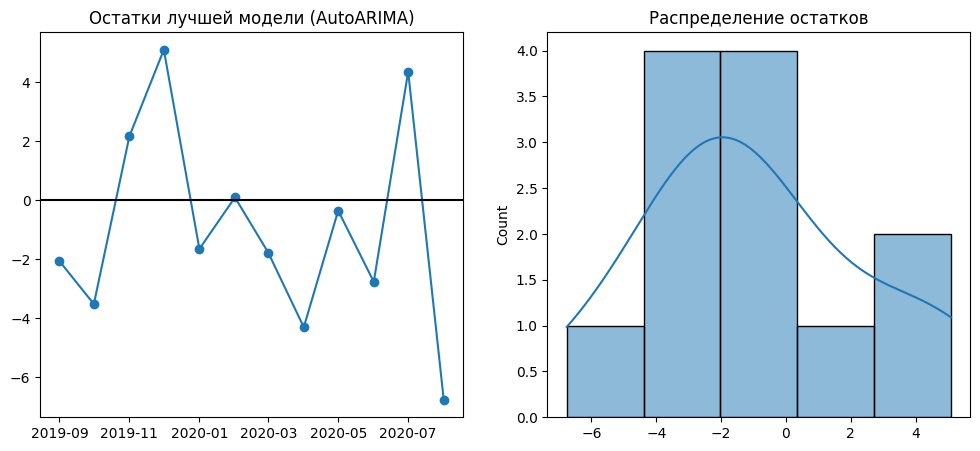

Тест Льюнга-Бокса на автокорреляцию остатков (лаги 1-6):
    lb_stat  lb_pvalue
1  0.930516   0.334729
2  0.932755   0.627270
3  1.509808   0.680008
4  1.679365   0.794463
5  1.723483   0.885928
6  1.862262   0.931920


In [28]:

if best_model_name == 'AutoARIMA':
    best_preds = forecasts_auto['AutoARIMA'].values
elif best_model_name == 'AutoETS':
    best_preds = forecasts_auto['AutoETS'].values
elif best_model_name == 'AutoTheta':
    best_preds = forecasts_auto['AutoTheta'].values
elif best_model_name == 'SeasonalNaive':
    best_preds = forecasts_baseline['SeasonalNaive'].values
else:
    best_preds = forecasts_baseline['Naive'].values

residuals = test.values - best_preds

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(test.index, residuals, marker='o')
plt.title('Остатки лучшей модели (AutoARIMA)')
plt.axhline(0, color='black')
plt.subplot(1,2,2)
sns.histplot(residuals, kde=True)
plt.title('Распределение остатков')
plt.savefig('results/2.png', dpi=150, bbox_inches='tight')
plt.show()

max_lag = min(6, len(residuals)//2)
lb_test = acorr_ljungbox(residuals, lags=range(1, max_lag+1), return_df=True)
print(f"Тест Льюнга-Бокса на автокорреляцию остатков (лаги 1-{max_lag}):")
print(lb_test)

слева: точки колеблются около нуля, не образуют тренда или систематических отклонений - это хорошо

справа: распределение остатков близко к нормальному, ошибки модели случайны и нет систематического перекоса

Тест Льюнга-Бокса:
гипотеза "Остатки не автокоррелированы" не отвергается → остатки действительно случайны, модель не упустила сезонных или трендовых зависимостей

Все три проверки (график остатков, распределение, тест Льюнга-Бокса) указывают на то, что модель AutoARIMA адекватна: она извлекла из ряда тренд и сезонность, а оставшаяся часть - белый шум. Значит, прогнозу можно доверять с точностью, выраженной метриками MAE/RMSE/sMAPE.

9. Вероятностные прогнозы



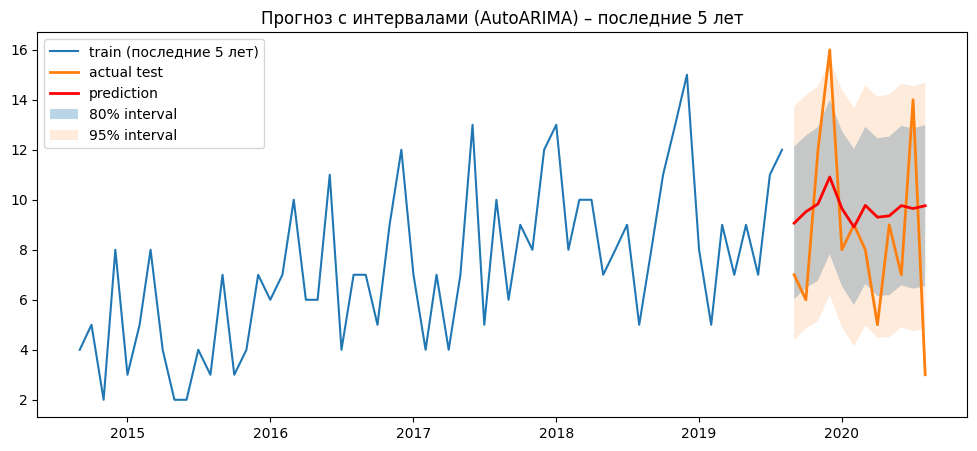

In [32]:
sf_best = StatsForecast(models=[AutoARIMA(season_length=12)], freq='MS', n_jobs=-1)
forecasts_intervals = sf_best.forecast(h=test_size, df=sf_train, level=[80, 95])
forecasts_intervals = forecasts_intervals.merge(test_df, on='ds', how='left')

cutoff_date = train.index[-60]
train_tail = train[train.index >= cutoff_date]

plt.figure(figsize=(12,5))
plt.plot(train_tail.index, train_tail.values, label='train (последние 5 лет)')
plt.plot(test.index, test.values, label='actual test', linewidth=2)
plt.plot(forecasts_intervals['ds'], forecasts_intervals['AutoARIMA'],
         label='prediction', color='red', linewidth=2)
plt.fill_between(forecasts_intervals['ds'],
                 forecasts_intervals['AutoARIMA-lo-80'],
                 forecasts_intervals['AutoARIMA-hi-80'],
                 alpha=0.3, label='80% interval')
plt.fill_between(forecasts_intervals['ds'],
                 forecasts_intervals['AutoARIMA-lo-95'],
                 forecasts_intervals['AutoARIMA-hi-95'],
                 alpha=0.15, label='95% interval')
plt.legend()
plt.title(f'Прогноз с интервалами ({best_model_name}) – последние 5 лет')
plt.savefig('results/forecast_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

Точечный прогноз AutoARIMA имеет малую вариабельность

## Итоговое сравнение моделей и выводы

сравнили 7 методов прогнозирования месячного числа космических запусков:

- **Бейзлайн:** Naive, SeasonalNaive  
- **Ручной подбор:** SARIMA(2,0,0)(0,1,1)[12]  
- **Автоматические:** AutoARIMA, AutoETS, AutoTheta  
- **Внешний эталон:** Prophet  

### 1. Сравнение метрик на тестовом периоде (12 месяцев)

| Модель | MAE | RMSE | sMAPE |
|--------|-----|------|-------|
| Naive | 4.33 | 4.88 | 46.3% |
| SeasonalNaive | 2.25 | 3.40 | 27.7% |
| Ручная SARIMA | 2.84  | 3.45  | 34.61% |
| AutoARIMA | 2.91 | 3.47 | 34.02% |
| AutoETS | 2.95 | 3.60 | 34.38% |
| AutoTheta | 2.97 | 3.61 | 34.69% |
| Prophet | 3.15 | 3.99 | 38.70% |


### 2. Результаты бектестинга (кросс-валидация, 5 окон)

Средние метрики по 5 окнам:

| Модель | MAE | RMSE | sMAPE |
|--------|-----|------|-------|
| Naive | 2.77 | 3.38 | 21.3% |
| SeasonalNaive | 2.87 | 3.42 | 23.6% |
| **AutoARIMA** | **2.21** | **2.82** | **16.7%** |
| AutoETS | 2.24 | 2.78 | 16.7% |
| AutoTheta | 2.21 | 2.77 | 16.5% |


### 3. Качественный анализ

**Наивные модели:**  
SeasonalNaive лучше обычного Naive благодаря учёту годовой сезонности

**Ручная SARIMA(2,0,0)(0,1,1)[12]:**  
Параметры модели обоснованы ADF-тестами и анализом ACF/PACF. Качество прогноза практически совпало с автоматическими аналогами, что подтверждает правильность ручного анализа.

**Автоматические модели (AutoARIMA, AutoETS, AutoTheta):**  
Все три модели показали близкие результаты. AutoARIMA чуть лучше по MAE на тесте (2.91), AutoTheta — минимальный RMSE в бектестинге (2.77).

**Prophet:**  
Модель корректно описала годовую сезонность и тренд, но дала наибольшие ошибки на тесте (MAE 3.15, sMAPE 38.7%). Возможная причина - относительно короткая история для автоматического выделения сложных сезонных паттернов либо переобучение на обучающем периоде. В текущей постановке Prophet не дал преимуществ перед классическими статистическими моделями.



### 4. Диагностика лучшей модели (AutoARIMA)

**Анализ остатков на тестовом периоде:**  
- График остатков не показывает систематических паттернов
- Гистограмма остатков близка к симметричной, что говорит об отсутствии систематического смещения
- Тест Льюнга–Бокса (лаги 1–6): все p‑значения > 0.05 (0.33–0.93) → нулевая гипотеза об отсутствии автокорреляции не отвергается

**Вероятностный прогноз:**  
- Точечный прогноз обладает крайне низкой вариабельностью
- Прогнозные интервалы (80% и 95%) оказались **широкими**, но при этом **фактические точки тестового периода регулярно выходили за их пределы**.  
- Это говорит о **недооценке неопределённости моделью**: истинная волатильность числа запусков выше, чем предполагает модель с нормально распределёнными ошибками.  
- Низкая вариабельность точечного прогноза и широкие интервалы создают ложное впечатление надёжности - фактически интервалы плохо калиброваны и не могут использоваться для оценки рисков без доработки.



### 5. Итоговая рекомендация

AutoARIMA может служить **хорошим базовым прогнозом среднего уровня запусков** (MAE ~2.2 в бектестинге), но **вероятностные оценки требуют осторожности** из-за неадекватной калибровки интервалов на тестовом периоде.

В текущем виде модель можно применять для **точечного прогнозирования с пониманием, что фактические значения могут значительно отклоняться от предсказаний**, а интервалы служат лишь ориентиром минимальной неопределённости. Для ответственных решений необходима доработка вероятностной части.